# Laboratory 6 – Exercises


# Exercise 1

Use the following dataset:

```python
X, y = make_blobs(
    n_samples=400,
    centers=4,
    cluster_std=1.25,
    random_state=42
),
```

in order to apply the original K-means clustering algorithm. Run the algorithm for 40 iterations and plot the model's decision boundaries.


In [23]:
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import math

In [24]:
X, y = make_blobs(n_samples=400, centers=4, cluster_std=1.25, random_state=42)

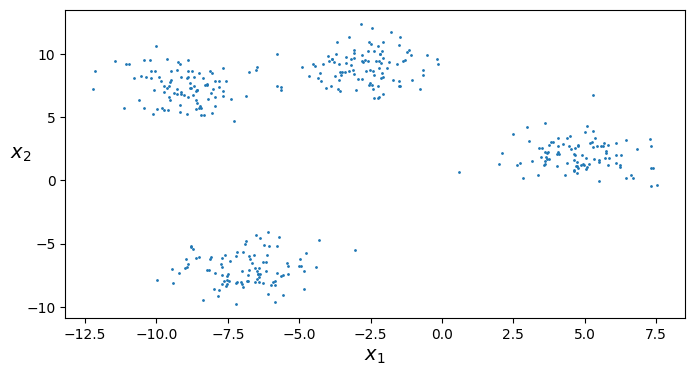

In [25]:
def plot_clusters(X, y=None):
    plt.scatter(X[:, 0], X[:, 1], c=y, s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)


plt.figure(figsize=(8, 4))
plot_clusters(X)
plt.show()

In [26]:
kmeans = KMeans(
    n_clusters=4,
    init="random",
    n_init=1,
    algorithm="lloyd",
    max_iter=40,
    random_state=42,
)
kmeans.fit(X)
print(kmeans.cluster_centers_)
print(kmeans.labels_)
print(kmeans.inertia_)
print(kmeans.n_iter_)
print(kmeans.n_features_in_)

[[ 5.69419575  1.62118179]
 [-5.80808665  8.22373041]
 [ 3.77693275  2.45194977]
 [-6.88493294 -7.00995279]]
[1 1 1 0 0 1 1 1 1 0 1 2 1 2 3 3 3 1 2 3 2 1 1 2 1 1 3 1 3 1 1 0 1 1 1 3 0
 2 1 3 1 1 1 3 2 0 1 3 1 2 1 1 3 0 0 1 2 1 1 0 3 2 1 3 1 1 3 3 3 1 1 3 1 2
 1 1 1 3 1 1 3 1 1 1 3 0 1 3 1 3 0 1 1 3 2 1 1 3 3 1 3 2 1 3 3 3 0 3 2 1 1
 1 0 0 1 1 1 2 1 1 3 2 1 1 1 3 3 2 3 1 1 1 3 1 3 1 1 3 1 3 1 3 3 2 1 1 3 1
 1 0 1 1 3 0 3 1 2 1 0 1 2 1 0 1 0 1 3 1 1 1 1 1 3 3 3 0 0 1 0 1 3 2 0 0 3
 0 1 1 3 3 2 1 1 2 3 3 1 3 1 1 2 1 3 1 1 0 1 1 1 3 1 0 0 1 0 3 3 0 1 2 3 1
 1 2 3 1 3 1 3 1 3 1 2 1 1 3 1 1 2 3 1 1 1 1 3 3 0 1 2 2 0 2 1 3 0 3 1 0 1
 1 1 2 0 1 1 3 3 3 1 0 0 3 3 0 1 3 1 1 0 1 1 0 3 1 1 1 1 1 1 0 0 1 2 2 3 1
 1 1 2 1 1 2 1 3 0 1 2 1 1 1 1 1 1 3 1 1 3 1 3 3 3 3 1 1 2 3 1 1 2 1 1 3 1
 2 1 3 1 1 1 1 1 3 2 1 1 0 0 1 1 1 2 2 1 0 1 2 0 1 0 1 1 1 3 3 1 3 0 3 3 1
 1 1 1 1 1 3 2 3 3 3 1 2 3 1 1 0 1 0 3 1 1 1 1 1 1 2 2 3 0 1]
3202.2990405308146
8
2


In [27]:
def plot_data(X):
    plt.plot(X[:, 0], X[:, 1], "k.", markersize=2)


def plot_centroids(centroids, weights=None, circle_color="w", cross_color="k"):
    if weights is not None:
        centroids = centroids[weights > weights.max() / 10]
    plt.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker="o",
        s=35,
        linewidths=8,
        color=circle_color,
        zorder=10,
        alpha=0.9,
    )
    plt.scatter(
        centroids[:, 0],
        centroids[:, 1],
        marker="x",
        s=35,
        linewidths=12,
        color=cross_color,
        zorder=11,
        alpha=1,
    )


def plot_decision_boundaries(clusterer, X, resolution=1000, show_centroids=True):
    mins = X.min(axis=0) - 0.1
    maxs = X.max(axis=0) + 0.1
    xx, yy = np.meshgrid(
        np.linspace(mins[0], maxs[0], resolution),
        np.linspace(mins[1], maxs[1], resolution),
    )
    Z = clusterer.predict(np.c_[xx.ravel(), yy.ravel()])
    Z = Z.reshape(xx.shape)

    plt.contourf(Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), cmap="Pastel2")
    plt.contour(
        Z, extent=(mins[0], maxs[0], mins[1], maxs[1]), linewidths=1, colors="k"
    )
    plot_data(X)
    if show_centroids:
        plot_centroids(clusterer.cluster_centers_)

    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)

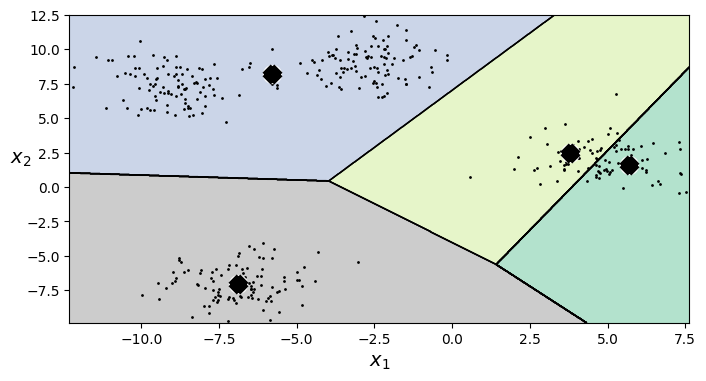

In [28]:
plt.figure(figsize=(8, 4))
plot_decision_boundaries(kmeans, X)
plt.show()

# Exercise 2

The following function is used to create a dataset with 2 features:

```python
def Circle(r,n):
    return [(math.cos(2*math.pi/n*x)*r+
            +np.random.normal(-30,30)+math.sin(2*math.pi/n*x)*r+
            +np.random.normal(-30,30)) for x in range(1,n+1)]
```

This function takes the radius and number of data points as arguments and returns an array of data points which when plotted forms a circle. In order to apply clustering algorithms, three concentric circles are created, and finally noise is added to the data as follows:

```python
df=pd.DataFrame(Circle(500,1000))
df=df.append(Circle(300,700))
df=df.append(Circle(100,300))

X=df.append([(np.random.randint(-600,600),
              np.random.randint(-600,600)) for i in range(300)])
```

Perform the following:

- ➤ plot the dataset;
- ➤ apply the K-means++ algorithm and plot the decision boundaries;
- ➤ apply the agglomerative clustering algorithm with complete linkage and visualize the clusters;
- ➤ apply the DBSCAN algorithm with eps=35 and min_samples=6, and plot the clusters.


In [29]:
def Circle(r, n):
    return [
        (
            math.cos(2 * math.pi / n * x) * r + np.random.normal(0, 30),
            math.sin(2 * math.pi / n * x) * r + np.random.normal(0, 30),
        )
        for x in range(1, n + 1)
    ]

In [30]:
df1 = pd.DataFrame(Circle(500, 1000))
df2 = pd.DataFrame(Circle(300, 700))
df3 = pd.DataFrame(Circle(100, 300))

df = pd.concat([df1, df2, df3], ignore_index=True)

In [31]:
noise = pd.DataFrame(
    [(np.random.randint(-600, 600), np.random.randint(-600, 600)) for i in range(300)]
)
X = pd.concat([df, noise], ignore_index=True)
X = np.array(X)

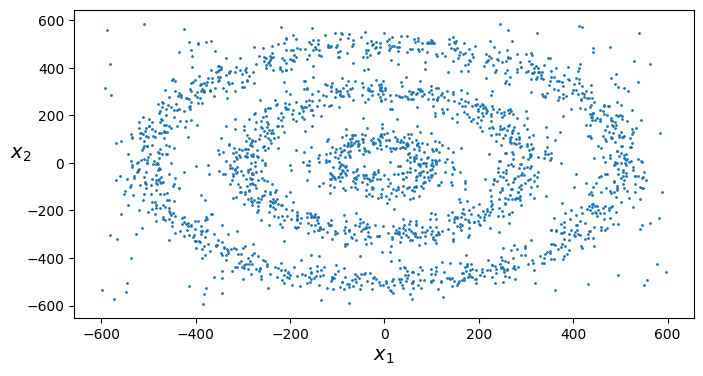

In [32]:
def plot_clusters(X):
    plt.figure(figsize=(8, 4))
    plt.scatter(X[:, 0], X[:, 1], s=1)
    plt.xlabel("$x_1$", fontsize=14)
    plt.ylabel("$x_2$", fontsize=14, rotation=0)
    plt.show()


plot_clusters(X)

In [33]:
k_means_pp = KMeans(n_clusters=5, init="k-means++", n_init=1, random_state=42)
k_means_pp.fit(X)

KMeans(n_clusters=5, n_init=1, random_state=42)

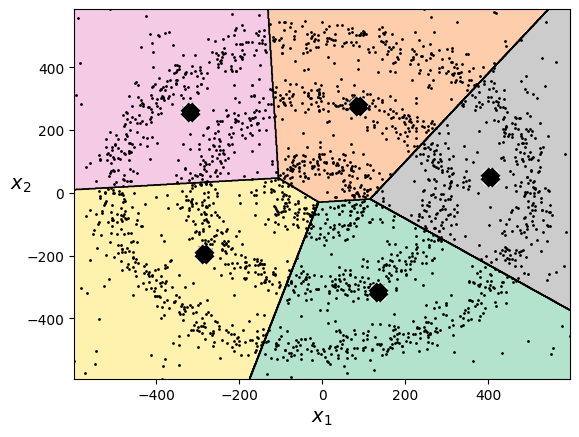

In [34]:
plot_decision_boundaries(k_means_pp, X)